# Plantalyze model
Modelo de machine learning para detección de especies de plantas a partir de imágenes.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import kagglehub
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Input,
    Reshape,
    Layer
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

 # Hiperparámetros

In [2]:
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
LEARNING_RATE = 0.0002
EPOCHS = 100

### Importar dataset

In [3]:
path = kagglehub.dataset_download("marquis03/plants-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plants-classification' dataset.
Path to dataset files: /kaggle/input/plants-classification


Nota: Este dataset ya estaba separado con una distribución de **70/20/10**, 70% train, 20% test y 10% validation.

In [4]:
train_dir = path + "/train"
test_dir = path + "/test"
val_dir = path + "/val"

### Redimensionar + Data Augmentation
Redimensionar todas las imágenes de 224x224. Además de añadir data augmentation con los datos de train.


Found 21000 images belonging to 30 classes.
Found 6000 images belonging to 30 classes.
Found 3000 images belonging to 30 classes.
(32, 224, 224, 3)


<Figure size 640x480 with 0 Axes>

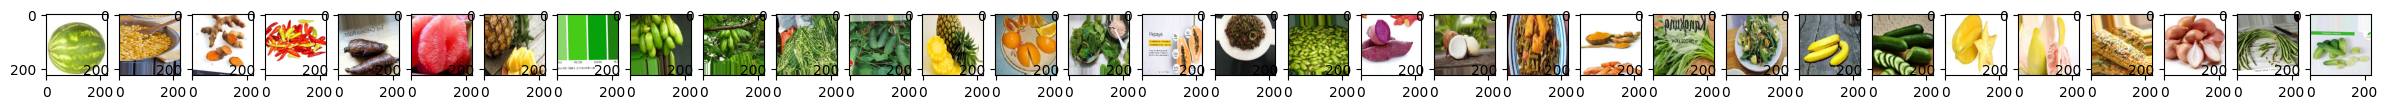

In [5]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 10,
    width_shift_range = 0.2,
    zoom_range = 0.3,
    horizontal_flip = True
    )

datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

images , labels = train_generator[0]

print(images.shape)

plt.figure()
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

### Capa de capsula

#### Función squash.

La función squash es la función de activación de la cápsula.

In [6]:
def squash(s, axis=-1):
    squared_norm  = tf.reduce_sum(tf.square(s), axis=axis, keepdims=True)
    safe_norm     = tf.sqrt(squared_norm + 1e-8)
    squash_factor = squared_norm / (1. + squared_norm)
    unit_vector   = s / safe_norm
    return squash_factor * unit_vector

#### Clase ConvCapsuleLayer
Es una capa personalizada que implementa una cápsula la cual busca transformar un vector de entrada y aplicarle **squash** como activación.

In [7]:
class ConvCapsuleLayer(Layer):
    def __init__(self, capsule_dim_out, **kwargs):
        super().__init__(**kwargs)
        self.capsule_dim_out = capsule_dim_out
        self.conv = Conv2D(capsule_dim_out, kernel_size=3, padding="same")

    def call(self, inputs):
        x = tf.squeeze(inputs, axis=3)
        x = self.conv(x)
        x = tf.expand_dims(x, 3)
        return squash(x)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'capsule_dim_out': self.capsule_dim_out})
        return cfg

### Arquitectura del modelo

In [8]:
def get_model_compiled():
  model = Sequential()
  model.add(Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

  model.add(Conv2D(16, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(32, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(64, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(128, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Reshape((14, 14, 1, 128)))
  model.add(ConvCapsuleLayer(256))
  model.add(Reshape((14, 14, 256)))
  model.add(Flatten())

  model.add(Dense(30, activation="softmax"))

  model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                loss="categorical_crossentropy",
                metrics=["accuracy"])

  return model

In [9]:
model = get_model_compiled()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 14, 14, 1, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_capsule_layer              │ (None, 14, 14, 1, 256) │       295,168 │
│ (ConvCapsuleLayer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │     1,505,310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,897,918 (7.24 MB)

 Trainable params: 1,897,918 (7.24 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Plantalyze

Mounted at /content/drive
/content/drive/MyDrive/Plantalyze


In [11]:
%cd /content/drive/MyDrive/Plantalyze/checkpoints/
%ls

/content/drive/MyDrive/Plantalyze/checkpoints
best_model_arq2_v4.keras       checkpoint_arq2_v4.weights.h5
checkpoint_arq2_v2.weights.h5  checkpoint_arq2_v5.weights.h5
checkpoint_arq2_v3.weights.h5  checkpoint_arq2.weights.h5


In [12]:
current_directory = "/content/drive/MyDrive/Plantalyze"
checkpoint_path = current_directory + "/checkpoints/checkpoint_arq2_v5.weights.h5"
checkpoint = ModelCheckpoint(filepath=checkpoint_path,
                             monitor='val_loss',
                             save_best_only=True,
                             save_weights_only=True,
                             verbose=1
)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [13]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop])

Epoch 1/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.1495 - loss: 2.9567
Epoch 1: val_loss improved from None to 2.28289, saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2_v5.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2_v5.weights.h5
657/657 ━━━━━━━━━━━━━━━━━━━━ 370s 551ms/step - accuracy: 0.2114 - loss: 2.6951 - val_accuracy: 0.3330 - val_loss: 2.2829
Epoch 2/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.3095 - loss: 2.3368
Epoch 2: val_loss improved from 2.28289 to 2.11470, saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2_v5.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2_v5.weights.h5
657/657 ━━━━━━━━━━━━━━━━━━━━ 271s 413ms/step - accuracy: 0.3205 - loss: 2.2977 - val_accuracy: 0.3747 - val_loss: 2.1147
Epoch 3/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.3618

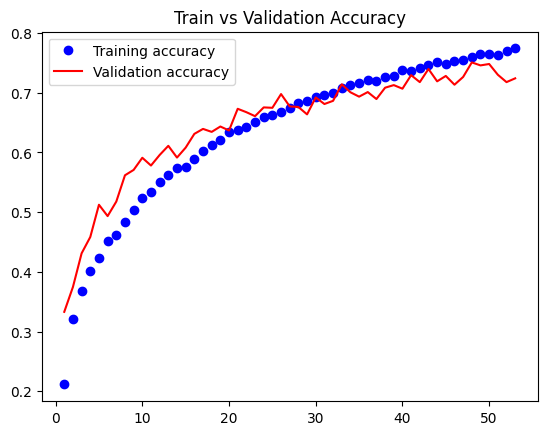

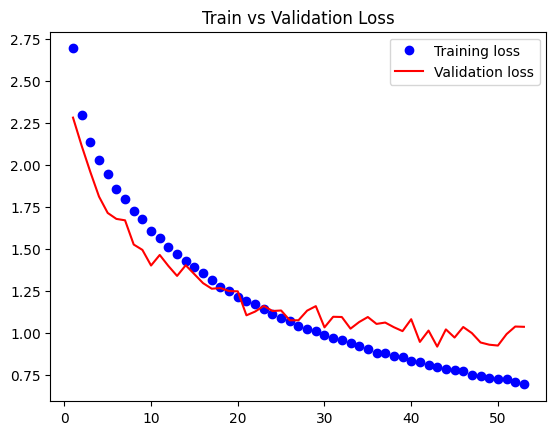

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.plot(epochs_range, acc, "bo", label="Training accuracy")
plt.plot(epochs_range, val_acc, "r", label="Validation accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()

plt.figure()

plt.plot(epochs_range, loss, "bo", label="Training loss")
plt.plot(epochs_range, val_loss, "r", label="Validation loss")
plt.title("Train vs Validation Loss")
plt.legend()

plt.show()

In [15]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc}")
print(f"Test loss: {test_loss}")

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

188/188 ━━━━━━━━━━━━━━━━━━━━ 37s 195ms/step - accuracy: 0.7245 - loss: 0.9427
Test accuracy: 0.7245000004768372
Test loss: 0.9427331686019897
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step


Classification Report:
               precision    recall  f1-score   support

     aloevera       0.88      0.73      0.80       200
       banana       0.62      0.56      0.59       200
      bilimbi       0.75      0.73      0.74       200
   cantaloupe       0.47      0.72      0.57       200
      cassava       0.70      0.71      0.71       200
      coconut       0.73      0.47      0.57       200
         corn       0.78      0.83      0.80       200
     cucumber       0.85      0.70      0.77       200
      curcuma       0.83      0.77      0.80       200
     eggplant       0.76      0.82      0.79       200
     galangal       0.73      0.86      0.79       200
       ginger       0.73      0.59      0.65       200
        guava       0.61      0.85      0.71       200
         kale       0.68      0.78      0.72       200
    longbeans       0.81      0.77      0.79       200
        mango       0.56      0.47      0.51       200
        melon       0.38      0.10      0

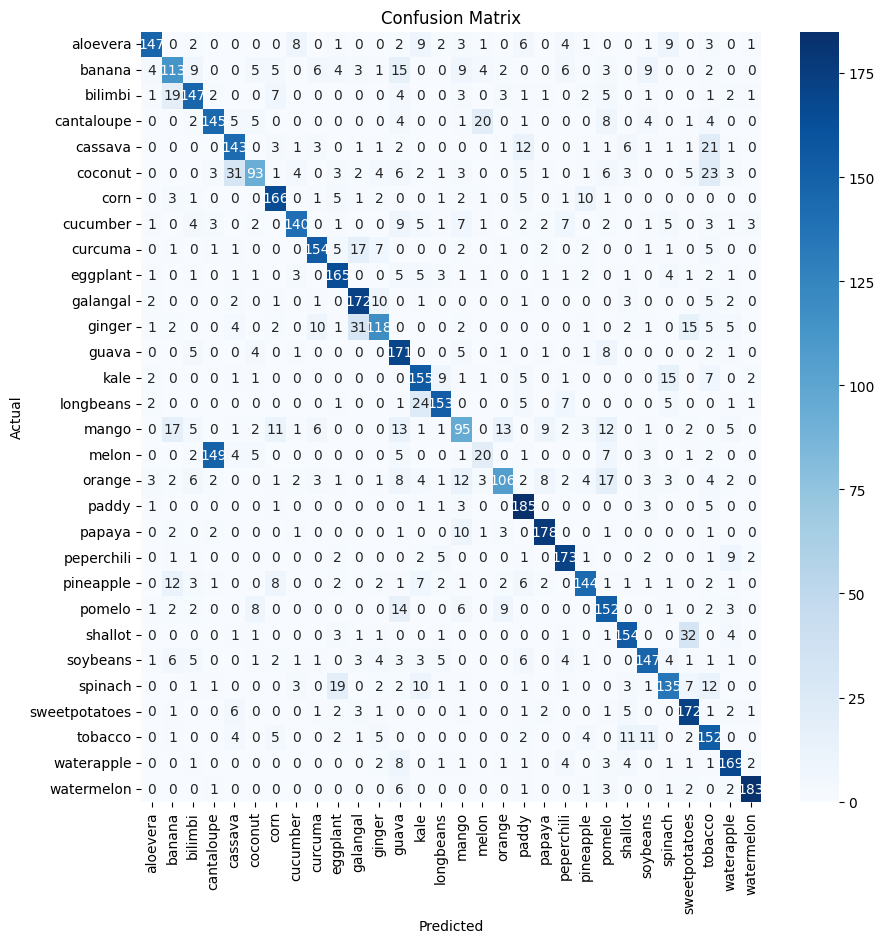

In [16]:
class_names = list(test_generator.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
)


conf_matrix = confusion_matrix(y_true, y_pred)

print("Classification Report:")
print(report)

plt.figure(figsize=(10, 10))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
